# 🏠 Wisconsin Real Estate Price Prediction (2026)
## Regresión - Predicción de `listPrice`

**Dataset:** [Wisconsin Real Estate Data 2026](https://www.kaggle.com/datasets/kanchana1990/wisconsin-real-estate-data-2026)

**Objetivo:** Predecir el precio de listado (`listPrice`) de propiedades inmobiliarias en Wisconsin usando múltiples modelos de regresión.

---

## 1. Importar módulos

In [1]:
# --- Módulos estándar ---
import os
import warnings
warnings.filterwarnings("ignore")

# --- Datos y matemáticas ---
import numpy as np
import pandas as pd

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# --- Scikit-learn: Preprocesamiento ---
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --- Scikit-learn: Modelos de regresión ---
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# --- Scikit-learn: Métricas ---
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error,
    mean_absolute_percentage_error,
    explained_variance_score,
)

# --- GridSearch ---
from sklearn.model_selection import GridSearchCV

print("✅ Módulos importados correctamente.")

✅ Módulos importados correctamente.


## 2. Funciones propias (utils)

In [2]:
def resumen_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Genera un resumen descriptivo completo del DataFrame."""
    resumen = pd.DataFrame({
        "dtype": df.dtypes,
        "n_nulos": df.isnull().sum(),
        "pct_nulos": (df.isnull().mean() * 100).round(2),
        "n_unicos": df.nunique(),
        "ejemplo": df.iloc[0] if len(df) > 0 else None,
    })
    return resumen


def plot_dispersion_vs_target(df: pd.DataFrame, num_cols: list, target: str, ncols: int = 3):
    """Scatter plots de variables numéricas vs variable objetivo."""
    nrows = int(np.ceil(len(num_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = axes.flatten()
    for i, col in enumerate(num_cols):
        axes[i].scatter(df[col], df[target], alpha=0.3, s=10, edgecolors="none")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(target)
        axes[i].set_title(f"{col} vs {target}")
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_boxplot_cat_vs_target(df: pd.DataFrame, cat_cols: list, target: str, ncols: int = 2):
    """Box plots de variables categóricas vs variable objetivo."""
    nrows = int(np.ceil(len(cat_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 5 * nrows))
    axes = np.array(axes).flatten()
    for i, col in enumerate(cat_cols):
        top_cats = df[col].value_counts().head(15).index
        subset = df[df[col].isin(top_cats)]
        sns.boxplot(data=subset, x=col, y=target, ax=axes[i])
        axes[i].set_title(f"{col} vs {target}")
        axes[i].tick_params(axis="x", rotation=45)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()


def evaluar_modelo(nombre: str, model, X_train, y_train, X_test, y_test) -> dict:
    """Evalúa un modelo de regresión con 6 métricas sobre train y test."""
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    resultados = {
        "modelo": nombre,
        # --- Train ---
        "MAE_train": mean_absolute_error(y_train, y_pred_train),
        "RMSE_train": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "R2_train": r2_score(y_train, y_pred_train),
        "MedAE_train": median_absolute_error(y_train, y_pred_train),
        "MAPE_train": mean_absolute_percentage_error(y_train, y_pred_train),
        "EVS_train": explained_variance_score(y_train, y_pred_train),
        # --- Test ---
        "MAE_test": mean_absolute_error(y_test, y_pred_test),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "R2_test": r2_score(y_test, y_pred_test),
        "MedAE_test": median_absolute_error(y_test, y_pred_test),
        "MAPE_test": mean_absolute_percentage_error(y_test, y_pred_test),
        "EVS_test": explained_variance_score(y_test, y_pred_test),
    }
    return resultados


def registrar_resultados(resultados_lista: list) -> pd.DataFrame:
    """Consolida una lista de diccionarios de resultados en un DataFrame comparativo."""
    df_res = pd.DataFrame(resultados_lista)
    df_res = df_res.set_index("modelo")
    return df_res.round(4)


print("✅ Funciones utils definidas.")

✅ Funciones utils definidas.


## 3. Descargar / Cargar Dataset

Se intenta descargar directamente desde Kaggle con la API. Si falla, se carga desde ruta local con `pd.read_csv`.

In [4]:
DATASET_SLUG = "kanchana1990/wisconsin-real-estate-data-2026"
CSV_FILENAME = "wisconsin_real_estate_data_2026.csv"
DOWNLOAD_DIR = "./data"

try:
    from kaggle.api.kaggle_api_extended import KaggleApi
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files(DATASET_SLUG, path=DOWNLOAD_DIR, unzip=True)
    csv_path = os.path.join(DOWNLOAD_DIR, CSV_FILENAME)
    print(f"✅ Dataset descargado desde Kaggle en: {csv_path}")
except Exception as e:
    print(f"⚠️ No se pudo descargar desde Kaggle: {e}")
    print("   → Cargando desde ruta local...")
    # ===== MODIFICAR ESTA RUTA si se descargó manualmente =====
    csv_path = os.path.join(DOWNLOAD_DIR, CSV_FILENAME)
    # csv_path = "ruta/al/archivo/wisconsin_real_estate_data_2026.csv"

df_raw = pd.read_csv(csv_path)
print(f"\n📊 Forma del dataset: {df_raw.shape}")
df_raw.head()

⚠️ No se pudo descargar desde Kaggle: No module named 'kaggle'
   → Cargando desde ruta local...

📊 Forma del dataset: (12643, 12)


,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built
0,single_family,NaN,Escape to the heart of the outdoors with this ...,350000.0,800.0,1.0,2.0,1.0,1.0,1.0,2.0,2018.0
1,single_family,NaN,Charming 3-bedroom ranch set on a beautiful wo...,369900.0,1144.0,1.0,3.0,4.0,3.0,3.0,2.0,1960.0
2,single_family,NaN,"ONLINE REAL ESTATE AUCTION [Redacted Entity], ...",199000.0,2326.0,2.0,4.0,2.0,2.0,2.0,3.0,1942.0
3,single_family,NaN,"Completely refreshed inside and out, this 2 be...",199900.0,944.0,NaN,2.0,1.0,1.0,1.0,NaN,1902.0
4,single_family,NaN,Modern equestrian retreat featuring a Gourmet ...,875000.0,3100.0,2.0,3.0,3.0,2.0,2.0,4.0,2004.0


## 4. Análisis Descriptivo

### 4.1 Información general y resumen estadístico

In [5]:
TARGET = "listPrice"

# Eliminar columna de texto libre (no se usará en regresión numérica)
df = df_raw.drop(columns=["text"], errors="ignore").copy()

print("=" * 60)
print("INFO DEL DATASET")
print("=" * 60)
df.info()
print("\n")

# Resumen propio
display(resumen_dataframe(df))

print("\n" + "=" * 60)
print("DESCRIBE (numéricas)")
print("=" * 60)
display(df.describe().T)

INFO DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12643 entries, 0 to 12642
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   type             12643 non-null  object 
 1   sub_type         1340 non-null   object 
 2   listPrice        12643 non-null  float64
 3   sqft             8652 non-null   float64
 4   stories          6095 non-null   float64
 5   beds             8937 non-null   float64
 6   baths            9357 non-null   float64
 7   baths_full       8838 non-null   float64
 8   baths_full_calc  8880 non-null   float64
 9   garage           7518 non-null   float64
 10  year_built       8613 non-null   float64
dtypes: float64(9), object(2)
memory usage: 1.1+ MB




,dtype,n_nulos,pct_nulos,n_unicos,ejemplo
type,object,0,0.00,11,single_family
sub_type,object,11303,89.40,2,NaN
listPrice,float64,0,0.00,2421,350000.0
sqft,float64,3991,31.57,2824,800.0
stories,float64,6548,51.79,4,1.0
beds,float64,3706,29.31,14,2.0
baths,float64,3286,25.99,14,1.0
baths_full,float64,3805,30.10,11,1.0
baths_full_calc,float64,3763,29.76,11,1.0
garage,float64,5125,40.54,16,2.0



DESCRIBE (numéricas)


,count,mean,std,min,25%,50%,75%,max
listPrice,12643.0,418997.709009,605797.560733,1.0,173000.00,309900.0,499863.50,23250000.0
sqft,8652.0,2027.823047,1133.813816,262.0,1360.75,1776.0,2387.25,21823.0
stories,6095.0,1.442658,0.511070,1.0,1.00,1.0,2.00,4.0
beds,8937.0,3.196151,1.088679,0.0,3.00,3.0,4.00,14.0
baths,9357.0,2.150369,1.172191,0.0,2.00,2.0,3.00,21.0
baths_full,8838.0,1.938561,0.844183,1.0,1.00,2.0,2.00,14.0
baths_full_calc,8880.0,1.967005,0.840825,1.0,1.00,2.0,2.00,14.0
garage,7518.0,2.310189,2.907575,1.0,2.00,2.0,3.00,225.0
year_built,8613.0,1975.593986,42.131142,1800.0,1950.00,1985.0,2008.00,2027.0


### 4.2 Dispersión: Variables numéricas vs `listPrice`

Variables numéricas (8): ['sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage', 'year_built']
Variables categóricas (2): ['type', 'sub_type']


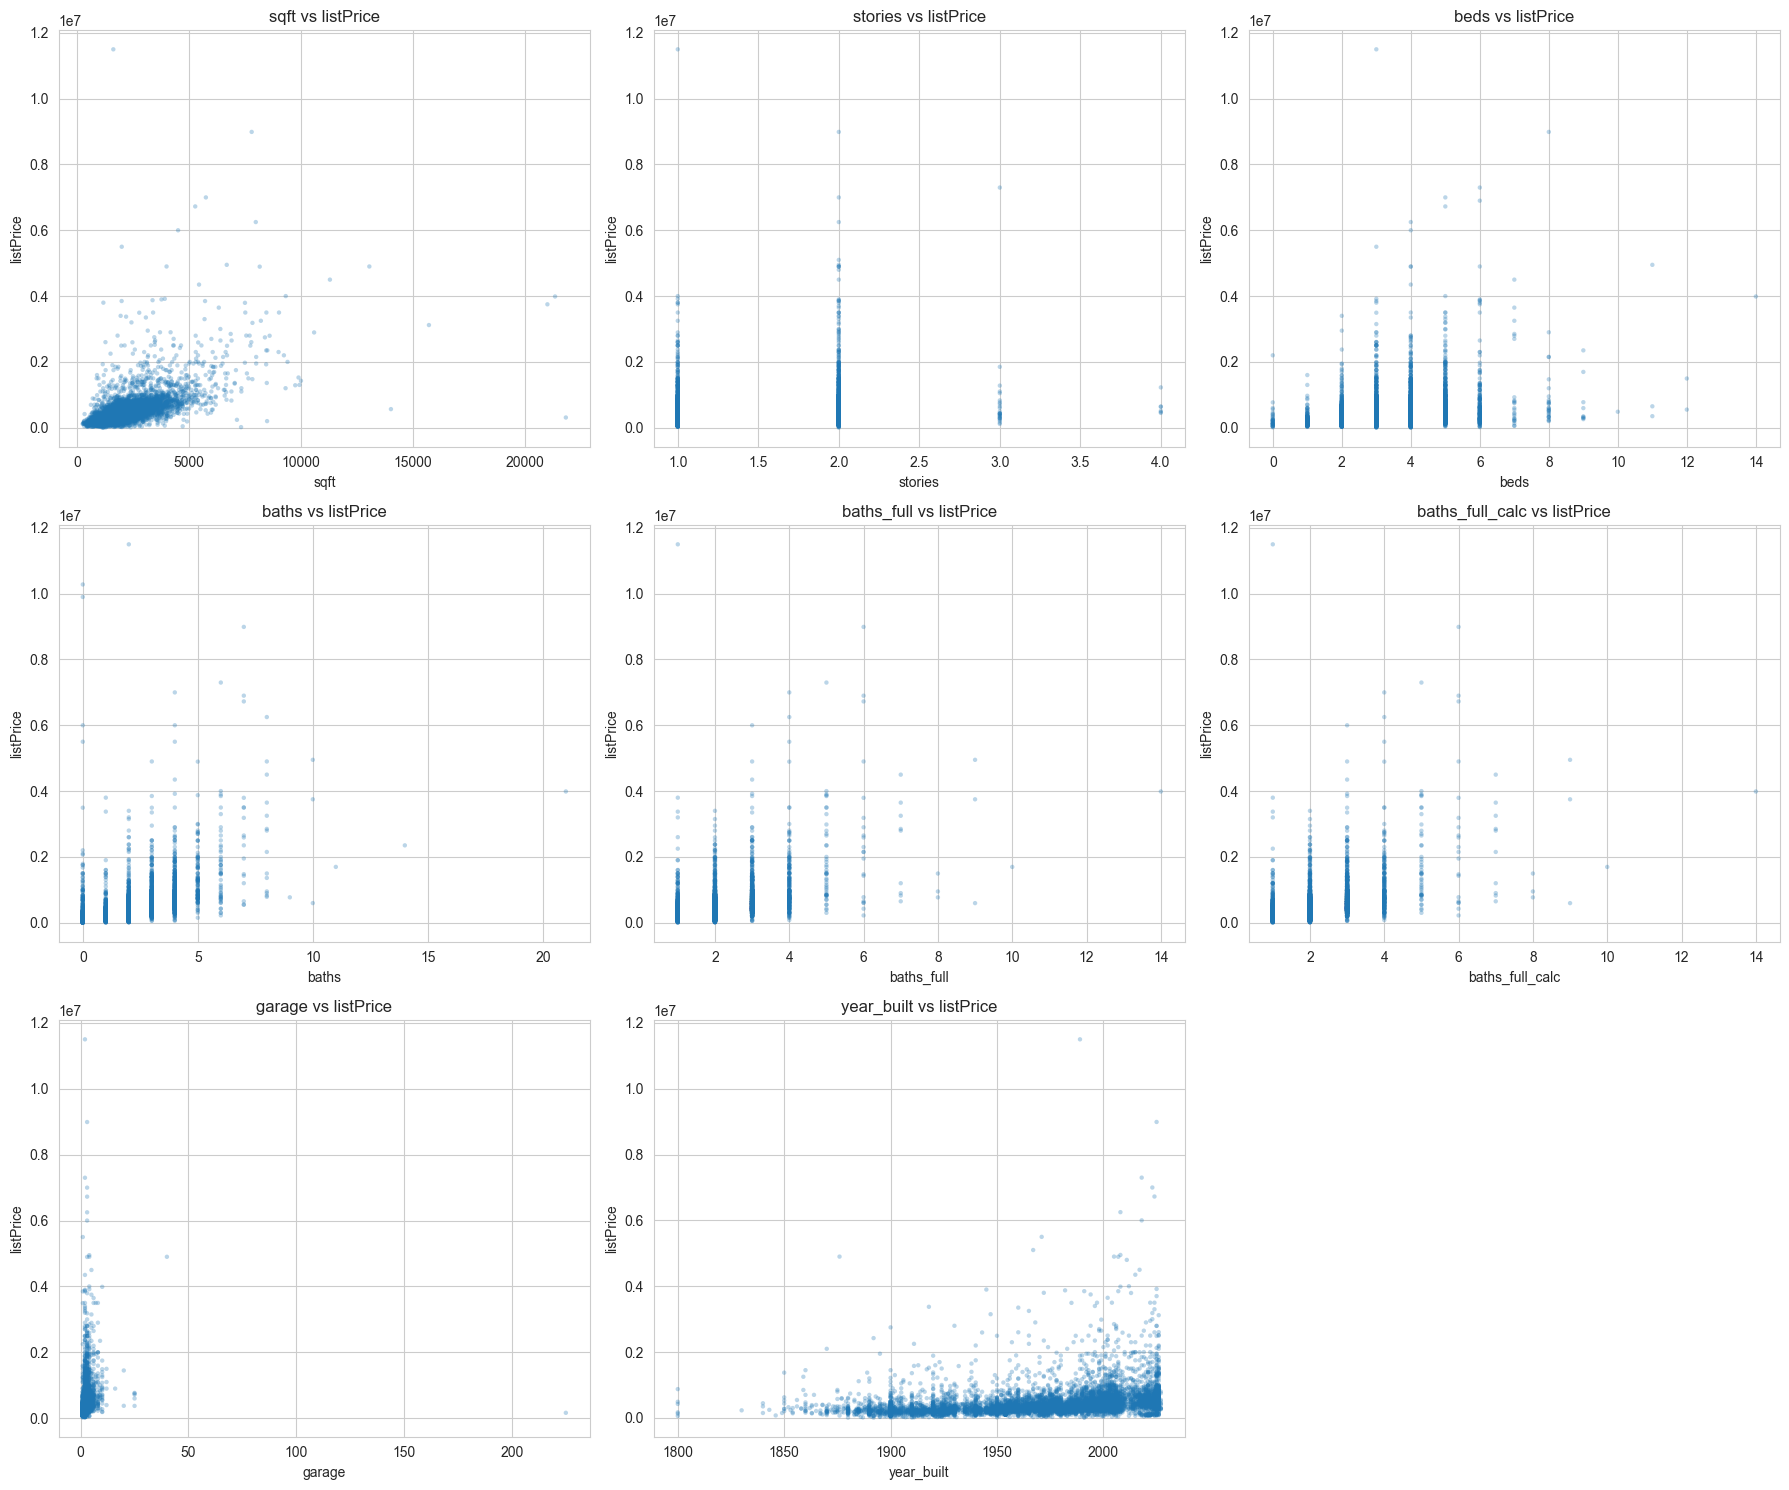

In [6]:
# Identificar columnas numéricas y categóricas
num_cols = df.select_dtypes(include=[np.number]).columns.drop(TARGET, errors="ignore").tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Variables numéricas ({len(num_cols)}): {num_cols}")
print(f"Variables categóricas ({len(cat_cols)}): {cat_cols}")

# Scatter plots
plot_dispersion_vs_target(df, num_cols, TARGET, ncols=3)

### 4.3 Boxplots: Variables categóricas vs `listPrice`

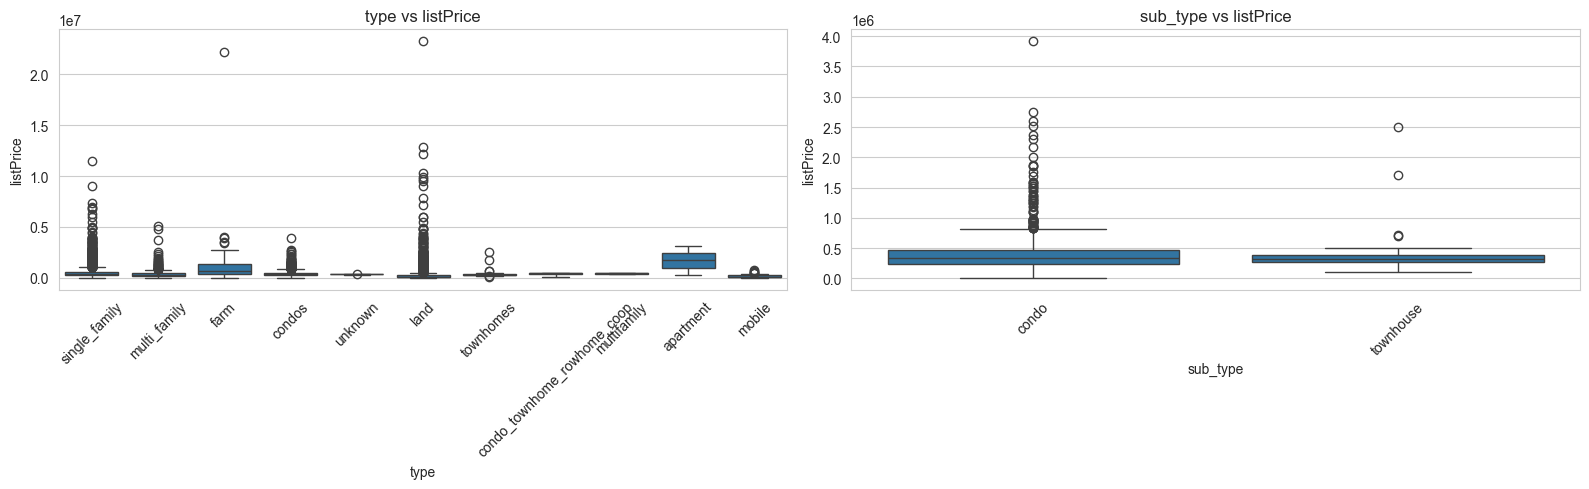

In [7]:
if cat_cols:
    plot_boxplot_cat_vs_target(df, cat_cols, TARGET, ncols=2)
else:
    print("No se encontraron variables categóricas.")

## 5. Partición Train / Test

In [8]:
# Separar features (X) y target (y)
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Partición 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"{'Conjunto':<12} {'Filas':>8} {'Columnas':>10}")
print("-" * 32)
print(f"{'X_train':<12} {X_train.shape[0]:>8} {X_train.shape[1]:>10}")
print(f"{'X_test':<12} {X_test.shape[0]:>8} {X_test.shape[1]:>10}")
print(f"{'y_train':<12} {y_train.shape[0]:>8} {'':>10}")
print(f"{'y_test':<12} {y_test.shape[0]:>8} {'':>10}")

Conjunto        Filas   Columnas
--------------------------------
X_train         10114         10
X_test           2529         10
y_train         10114           
y_test           2529           


## 6. Pipeline de Preprocesamiento

- **Numéricas:** Imputar con mediana → Escalar (StandardScaler)
- **Categóricas:** Imputar con moda → OneHotEncoder

Se ajusta (`fit`) sobre train y se transforma sobre train y test.

In [9]:
# Identificar columnas por tipo en el conjunto de entrenamiento
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Features numéricas ({len(num_features)}): {num_features}")
print(f"Features categóricas ({len(cat_features)}): {cat_features}")

# --- Pipeline numérico ---
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# --- Pipeline categórico ---
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# --- ColumnTransformer ---
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, num_features),
    ("cat", categorical_pipeline, cat_features),
], remainder="drop")

# Ajustar sobre train
X_train_prep = preprocessor.fit_transform(X_train)
# Transformar sobre test
X_test_prep = preprocessor.transform(X_test)

print(f"\n✅ Datos preprocesados:")
print(f"   X_train_prep shape: {X_train_prep.shape}")
print(f"   X_test_prep shape:  {X_test_prep.shape}")

Features numéricas (8): ['sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage', 'year_built']
Features categóricas (2): ['type', 'sub_type']

✅ Datos preprocesados:
   X_train_prep shape: (10114, 21)
   X_test_prep shape:  (2529, 21)


## 7. Ajuste de Modelos de Regresión

Se entrenan **6 modelos** con `GridSearchCV` (al menos 3 hiperparámetros por modelo). La data ya está lista en `X_train_prep` / `X_test_prep`.

In [10]:
# Lista para almacenar resultados de evaluación
resultados = []

### 7.1 Linear Regression (baseline)

In [11]:
lr_params = {
    "fit_intercept": [True, False],
    "positive": [True, False],
    "copy_X": [True],
}

gs_lr = GridSearchCV(LinearRegression(), lr_params, cv=5, scoring="r2", n_jobs=-1)
gs_lr.fit(X_train_prep, y_train)

print(f"Mejores params: {gs_lr.best_params_}")
print(f"Mejor R² (CV):  {gs_lr.best_score_:.4f}")

resultados.append(evaluar_modelo("LinearRegression", gs_lr.best_estimator_,
                                  X_train_prep, y_train, X_test_prep, y_test))

Mejores params: {'copy_X': True, 'fit_intercept': False, 'positive': False}
Mejor R² (CV):  0.1940


### 7.2 Ridge Regression

In [12]:
ridge_params = {
    "alpha": [0.01, 0.1, 1.0, 10.0, 100.0],
    "fit_intercept": [True, False],
    "solver": ["auto", "svd", "cholesky"],
}

gs_ridge = GridSearchCV(Ridge(), ridge_params, cv=5, scoring="r2", n_jobs=-1)
gs_ridge.fit(X_train_prep, y_train)

print(f"Mejores params: {gs_ridge.best_params_}")
print(f"Mejor R² (CV):  {gs_ridge.best_score_:.4f}")

resultados.append(evaluar_modelo("Ridge", gs_ridge.best_estimator_,
                                  X_train_prep, y_train, X_test_prep, y_test))

Mejores params: {'alpha': 1.0, 'fit_intercept': False, 'solver': 'svd'}
Mejor R² (CV):  0.1944


### 7.3 Lasso Regression

In [13]:
lasso_params = {
    "alpha": [0.01, 0.1, 1.0, 10.0, 100.0],
    "fit_intercept": [True, False],
    "max_iter": [1000, 5000, 10000],
}

gs_lasso = GridSearchCV(Lasso(), lasso_params, cv=5, scoring="r2", n_jobs=-1)
gs_lasso.fit(X_train_prep, y_train)

print(f"Mejores params: {gs_lasso.best_params_}")
print(f"Mejor R² (CV):  {gs_lasso.best_score_:.4f}")

resultados.append(evaluar_modelo("Lasso", gs_lasso.best_estimator_,
                                  X_train_prep, y_train, X_test_prep, y_test))

Mejores params: {'alpha': 100.0, 'fit_intercept': False, 'max_iter': 1000}
Mejor R² (CV):  0.1948


### 7.4 Decision Tree Regressor

In [14]:
dt_params = {
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10],
}

gs_dt = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_params,
                     cv=5, scoring="r2", n_jobs=-1)
gs_dt.fit(X_train_prep, y_train)

print(f"Mejores params: {gs_dt.best_params_}")
print(f"Mejor R² (CV):  {gs_dt.best_score_:.4f}")

resultados.append(evaluar_modelo("DecisionTree", gs_dt.best_estimator_,
                                  X_train_prep, y_train, X_test_prep, y_test))

Mejores params: {'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}
Mejor R² (CV):  0.1984


### 7.5 Random Forest Regressor

In [15]:
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
}

gs_rf = GridSearchCV(RandomForestRegressor(random_state=42), rf_params,
                     cv=5, scoring="r2", n_jobs=-1)
gs_rf.fit(X_train_prep, y_train)

print(f"Mejores params: {gs_rf.best_params_}")
print(f"Mejor R² (CV):  {gs_rf.best_score_:.4f}")

resultados.append(evaluar_modelo("RandomForest", gs_rf.best_estimator_,
                                  X_train_prep, y_train, X_test_prep, y_test))

Mejores params: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 100}
Mejor R² (CV):  0.2258


### 7.6 Gradient Boosting Regressor

In [16]:
gb_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
}

gs_gb = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_params,
                     cv=5, scoring="r2", n_jobs=-1)
gs_gb.fit(X_train_prep, y_train)

print(f"Mejores params: {gs_gb.best_params_}")
print(f"Mejor R² (CV):  {gs_gb.best_score_:.4f}")

resultados.append(evaluar_modelo("GradientBoosting", gs_gb.best_estimator_,
                                  X_train_prep, y_train, X_test_prep, y_test))

Mejores params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300}
Mejor R² (CV):  0.2215


## 8. Evaluación Comparativa de Modelos

Se consolidan las **6 métricas** (MAE, RMSE, R², MedAE, MAPE, EVS) evaluadas en Train y Test para los 6 modelos.

In [17]:
# Tabla comparativa
df_resultados = registrar_resultados(resultados)
display(df_resultados)

,MAE_train,RMSE_train,R2_train,MedAE_train,MAPE_train,EVS_train,MAE_test,RMSE_test,R2_test,MedAE_test,MAPE_test,EVS_test
modelo,,,,,,,,,,,,
LinearRegression,198843.0884,519942.0049,0.1914,124758.5637,620.4201,0.1914,207668.7435,653603.6678,0.1412,123332.0601,829.1041,0.1414
Ridge,198836.5462,519947.4379,0.1913,124824.3359,612.7811,0.1913,207661.3938,653774.7988,0.1407,123825.7901,821.4572,0.1410
Lasso,198922.0240,519962.3901,0.1913,124819.3739,610.3832,0.1913,207724.4562,653832.4973,0.1406,124326.9404,819.3840,0.1408
DecisionTree,183414.6190,499461.6093,0.2538,106973.7341,650.4298,0.2538,206025.4680,665270.1844,0.1102,114950.0000,848.5289,0.1104
RandomForest,152085.9658,466622.3304,0.3487,77348.9611,619.9945,0.3487,195852.9473,649512.3584,0.1519,99065.7291,816.6218,0.1519
GradientBoosting,179469.8849,481275.7381,0.3072,111750.3076,585.2672,0.3072,199149.6391,653868.5228,0.1405,111145.2771,789.1944,0.1406


### 8.1 Visualización: R² Test por modelo

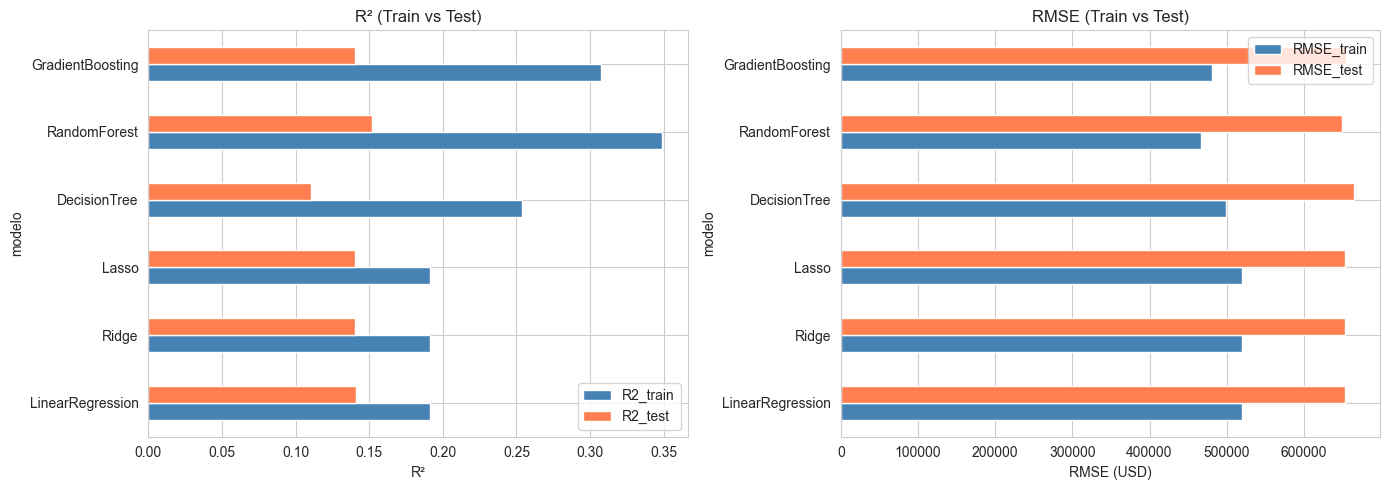


🏆 Mejor modelo por R² en Test:
   RandomForest → R² = 0.1519


In [18]:
# Comparar R² en Train vs Test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R²
df_resultados[["R2_train", "R2_test"]].plot(kind="barh", ax=axes[0], color=["steelblue", "coral"])
axes[0].set_title("R² (Train vs Test)")
axes[0].set_xlabel("R²")

# RMSE
df_resultados[["RMSE_train", "RMSE_test"]].plot(kind="barh", ax=axes[1], color=["steelblue", "coral"])
axes[1].set_title("RMSE (Train vs Test)")
axes[1].set_xlabel("RMSE (USD)")

plt.tight_layout()
plt.show()

print("\n🏆 Mejor modelo por R² en Test:")
print(f"   {df_resultados['R2_test'].idxmax()} → R² = {df_resultados['R2_test'].max():.4f}")